In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/american-sign-language/README.dataset.txt
/kaggle/input/american-sign-language/README.roboflow.txt
/kaggle/input/american-sign-language/data.yaml
/kaggle/input/american-sign-language/valid/labels/L14_jpg.rf.92049f347e38b9d3936e809ec728e743.txt
/kaggle/input/american-sign-language/valid/labels/I13_jpg.rf.c32c078b577f7727b8c2949cd2195d00.txt
/kaggle/input/american-sign-language/valid/labels/Z11_jpg.rf.5d84b9efcd82f5600f37f0755ba27e78.txt
/kaggle/input/american-sign-language/valid/labels/R20_jpg.rf.a5ccb35a4661c7c3176335551962f262.txt
/kaggle/input/american-sign-language/valid/labels/U3_jpg.rf.10da012fc7f7c9c4a04a9c2f8df0fd67.txt
/kaggle/input/american-sign-language/valid/labels/F0_jpg.rf.b29817aebbe027b884d28070f2838080.txt
/kaggle/input/american-sign-language/valid/labels/Z4_jpg.rf.d3d5ad6afa67b35c3d5f54779b103c6a.txt
/kaggle/input/american-sign-language/valid/labels/H15_jpg.rf.a280320c27d08e7a2a48a2508533e3aa.txt
/kaggle/input/american-sign-language/valid/labels/Y17_jpg.r

In [2]:
!pip install ultralytics 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.4 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import os
from IPython.display import Image, display
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
!ls /kaggle/input/

american-sign-language


In [5]:
DATASET_NAME = 'american-sign-language'  # Example: 'american-sign-language-yolov11'

# Define paths
dataset_zip_path = f'/kaggle/input/american-sign-language'
extract_path = '/kaggle/working/asl_dataset'

# Check if zip file exists
if os.path.exists(dataset_zip_path):
    print(f"✓ Found dataset at: {dataset_zip_path}")
else:
    print(f"✗ Dataset not found at: {dataset_zip_path}")
    print("\nPlease check:")
    print("1. You've uploaded the dataset to Kaggle")
    print("2. You've added it to this notebook using 'Add Data'")
    print("3. The DATASET_NAME variable matches your dataset folder name")

✓ Found dataset at: /kaggle/input/american-sign-language


In [6]:

dataset_path = f'/kaggle/input/{DATASET_NAME}'

print("Checking dataset structure...")
!ls {dataset_path}

print("\nDataset is ready to use!")

Checking dataset structure...
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid

Dataset is ready to use!


In [7]:
import os

print("Dataset Structure:")
print("="*50)

for folder in ['train', 'valid', 'test']:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.exists(folder_path):
        images_path = os.path.join(folder_path, 'images')
        labels_path = os.path.join(folder_path, 'labels')
        
        if os.path.exists(images_path) and os.path.exists(labels_path):
            images_count = len(os.listdir(images_path))
            labels_count = len(os.listdir(labels_path))
            print(f"{folder:8s}: {images_count} images, {labels_count} labels")
        else:
            print(f"{folder:8s}: Folder exists but missing images/labels")
    else:
        print(f"{folder:8s}: Not found")

Dataset Structure:
train   : 1512 images, 1512 labels
valid   : 144 images, 144 labels
test    : 72 images, 72 labels


In [8]:
# Read the original data.yaml from the dataset
yaml_path = os.path.join(dataset_path, 'data.yaml')

if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        print("Original data.yaml:")
        print("="*50)
        print(f.read())
else:
    print(f"data.yaml not found at: {yaml_path}")
    print("\nChecking what files exist in dataset:")
    !ls {dataset_path}

Original data.yaml:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 26
names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

roboflow:
  workspace: david-lee-d0rhs
  project: american-sign-language-letters
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/david-lee-d0rhs/american-sign-language-letters/dataset/1


In [9]:
# Create updated data.yaml for training
yaml_content = f"""path: {dataset_path}
train: train/images
val: valid/images
test: test/images

nc: 26
names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
"""

# Save to working directory (Kaggle input is read-only)
yaml_path = '/kaggle/working/data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✓ data.yaml updated successfully!")
print(f"\nSaved at: {yaml_path}")
print("\nNew data.yaml content:")
print("="*50)
print(yaml_content)

✓ data.yaml updated successfully!

Saved at: /kaggle/working/data.yaml

New data.yaml content:
path: /kaggle/input/american-sign-language
train: train/images
val: valid/images
test: test/images

nc: 26
names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']



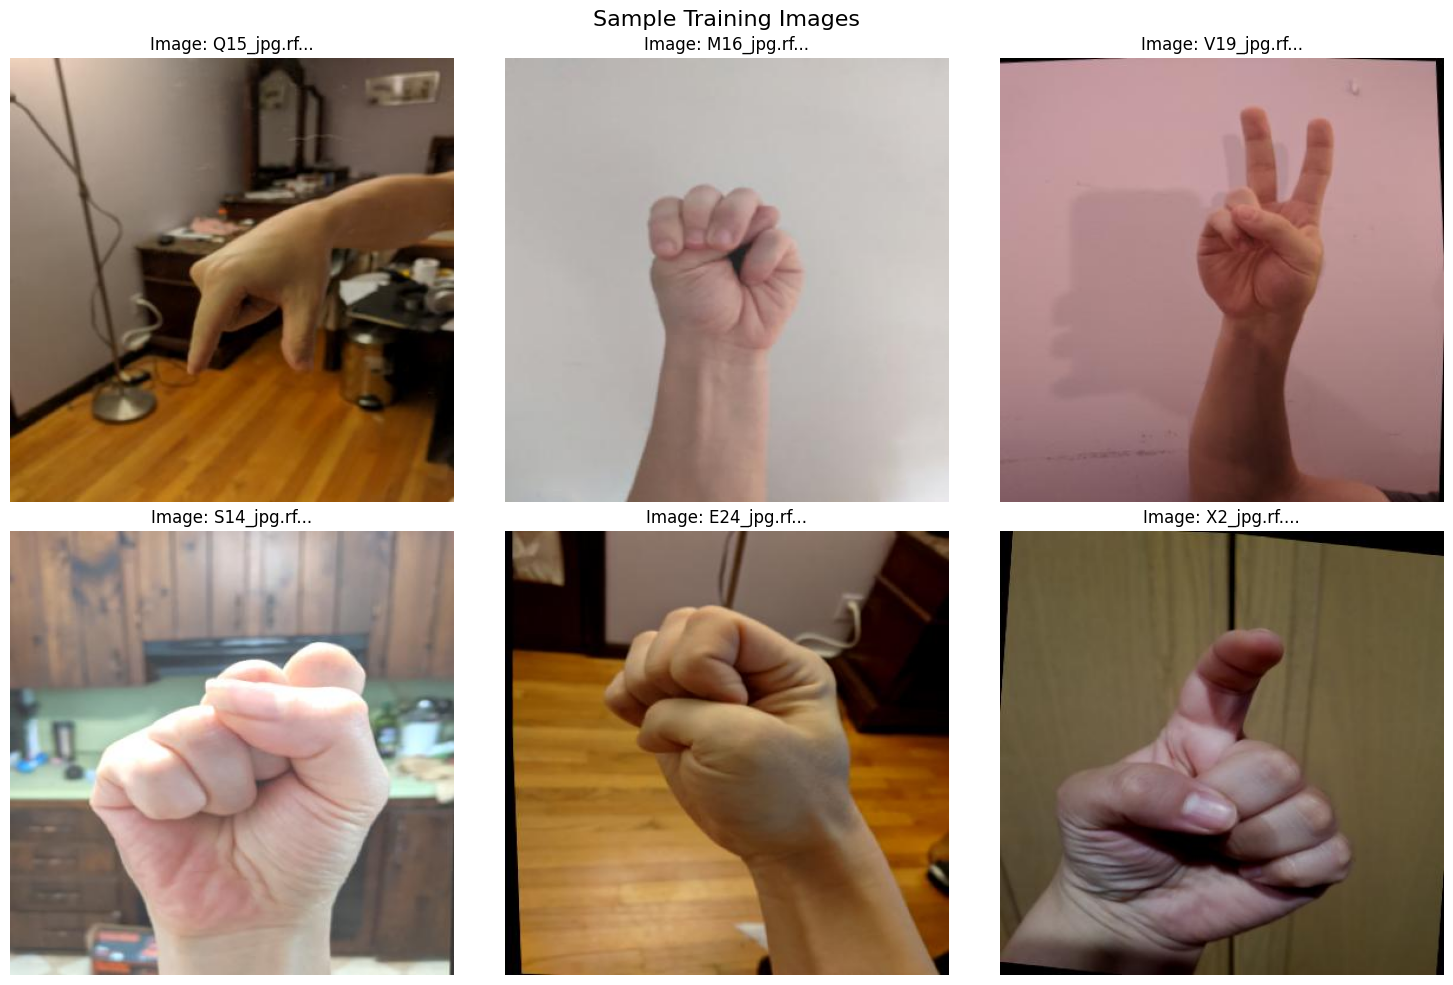

In [10]:
import random
import cv2
from matplotlib import pyplot as plt

# Get sample images from training set
train_images_path = os.path.join(dataset_path, 'train', 'images')
sample_images = random.sample(os.listdir(train_images_path), 6)

# Display samples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sample Training Images', fontsize=16)

for idx, img_name in enumerate(sample_images):
    img_path = os.path.join(train_images_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax = axes[idx // 3, idx % 3]
    ax.imshow(img)
    ax.set_title(f"Image: {img_name[:10]}...")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Training configuration
MODEL_SIZE = 'yolo11n.pt'  # Change to yolo11s.pt, yolo11m.pt for better accuracy
EPOCHS = 50                # Increase to 100+ for better results
IMG_SIZE = 640             # Image size for training
BATCH_SIZE = 16            # Reduce to 8 if you get memory errors

print(f"Training Configuration:")
print("="*50)
print(f"Model: {MODEL_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Dataset: {yaml_path}")

Training Configuration:
Model: yolo11n.pt
Epochs: 50
Image Size: 640
Batch Size: 16
Dataset: /kaggle/working/data.yaml


In [12]:
from ultralytics import YOLO

# Initialize YOLO model
model = YOLO(MODEL_SIZE)

print("✓ Model loaded successfully!")
print(f"Starting training for {EPOCHS} epochs...")
print("="*70)

✓ Model loaded successfully!
Starting training for 50 epochs...


In [13]:
# Train the model
results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name='asl_yolo11',
    patience=10,           
    save=True,            
    device=0,              
    workers=2,             
    verbose=True,          
    plots=True          
)

print("\n" + "="*70)
print("✓ Training completed successfully!")
print("="*70)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=asl_yolo11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, p